In [14]:
import os # Configure which GPU
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

# Import Sionna
try:
    import sionna as sn
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Import PyTorch
import torch

import numpy as np

# For plotting
%matplotlib inline
# also try %matplotlib widget

import matplotlib.pyplot as plt

# for performance measurements
import time

在本次實驗中將實作OFDM以及Channel estimation到系統中，並比較Perfect CSI和Imperfect CSI對系統效能的影響

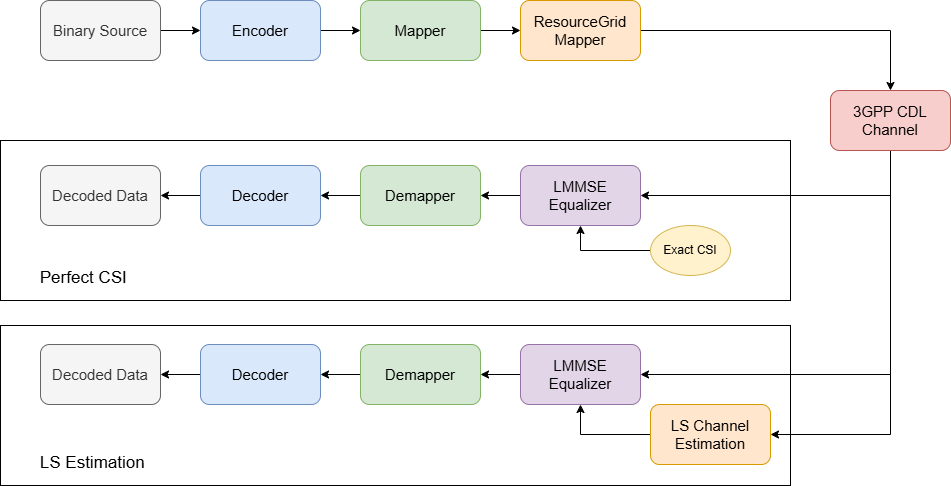

## Stream Management
For any type of MIMO simulations, it is required to setup a `StreamManagement` object. It determines which transmitters and receivers communicate data streams with each other. In our scenario, we will configure a single UT equipped with a single antenna and a single BS equipped with multiple antennas. Whether the UT or BS is considered as a transmitter depends on the link direction, which can be either uplink or downlink. The `StreamManagement` has many properties that are used by other components, such as precoding and equalization.

We will configure the system here such that the number of streams per transmitter is equal to the number of UT antennas.

In [15]:
# Define the number of UT and BS antennas
NUM_UT = 1
NUM_BS = 1
NUM_UT_ANT = 1
NUM_BS_ANT = 4

# The number of transmitted streams is equal to the number of UT antennas
# in both uplink and downlink
NUM_STREAMS_PER_TX = NUM_UT_ANT

# Create an RX-TX association matrix.
# RX_TX_ASSOCIATION[i,j]=1 means that receiver i gets at least one stream
# from transmitter j. Depending on the transmission direction (uplink or downlink),
# the role of UT and BS can change.
# For example, considering a system with 2 RX and 4 TX, the RX-TX
# association matrix could be
# [ [1 , 1, 0, 0],
#   [0 , 0, 1, 1] ]
# which indicates that the RX 0 receives from TX 0 and 1, and RX 1 receives from
# TX 2 and 3.
#
# In this notebook, as we have only a single transmitter and receiver,
# the RX-TX association matrix is simply:
RX_TX_ASSOCIATION = np.array([[1]])

# Instantiate a StreamManagement object
# This determines which data streams are determined for which receiver.
# In this simple setup, this is fairly straightforward. However,
# in setups with multiple transmitters and receivers, the stream management
# is more involved.
STREAM_MANAGEMENT = sn.phy.mimo.StreamManagement(RX_TX_ASSOCIATION, NUM_STREAMS_PER_TX)

## Resource Grid
We will also configure a `ResourceGrid` object. It is used to allocate data symbols and pilot symbols on the resource grid. In this notebook, we use a kronecker pilot pattern as example.

In [16]:
RESOURCE_GRID = sn.phy.ofdm.ResourceGrid(num_ofdm_symbols=14,    # Number of OFDM symbols in one slot
                                         fft_size=76, # the number of subcarriers
                                         subcarrier_spacing=30e3, # Subcarrier spacing [Hz]
                                         num_tx=NUM_UT, # Number of transmitters. Defaults to 1.
                                         num_streams_per_tx=NUM_STREAMS_PER_TX,  # Number of streams per transmitter. Defaults to 1.
                                         cyclic_prefix_length=6,  # Length of the cyclic prefix. Defaults to 0.
                                         pilot_pattern="kronecker", # Set the pilot parrern
                                         pilot_ofdm_symbol_indices=[2, 11]) # List of indices of OFDM symbols reserved for pilot transmissions. 
                                                                            # Only needed if pilot_pattern="kronecker".

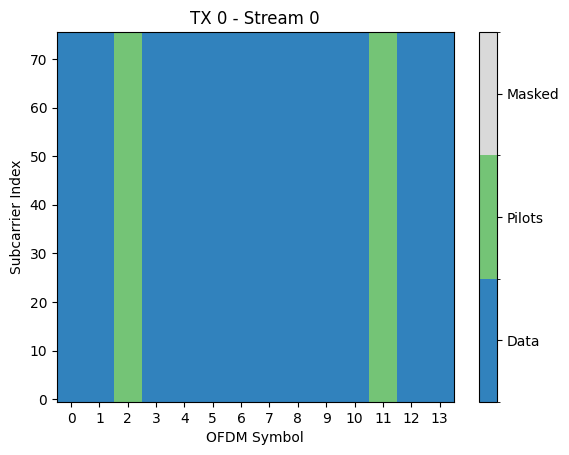

In [17]:
RESOURCE_GRID.pilot_pattern.show();

Antenna Arrays
We use the `Antenna` and `AntennaArray` classes from the 3GPP TR38.901 channel model to configure our antenna elements and arrays. The `Antenna` class consists of a single antenna element, whereas the `AntennaArray` class consists of multiple antenna elements.

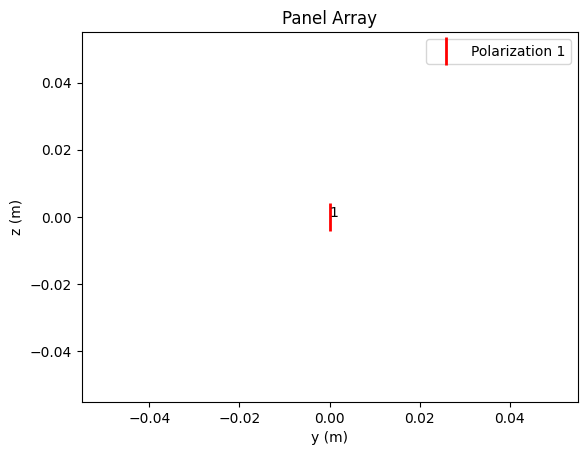

In [18]:
CARRIER_FREQUENCY = 2.6e9 # Carrier frequency in Hz.
                          # This is needed here to define the antenna element spacing.

UT_ARRAY = sn.phy.channel.tr38901.Antenna(polarization="single",
                                          polarization_type="V",
                                          antenna_pattern="38.901",
                                          carrier_frequency=CARRIER_FREQUENCY)
UT_ARRAY.show();

BS_ARRAY = sn.phy.channel.tr38901.AntennaArray(num_rows=1,
                                               num_cols=int(NUM_BS_ANT/2),
                                               polarization="dual",
                                               polarization_type="cross",
                                               antenna_pattern="38.901",
                                               carrier_frequency=CARRIER_FREQUENCY)

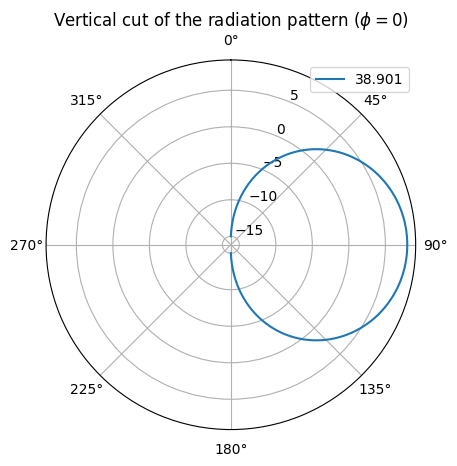

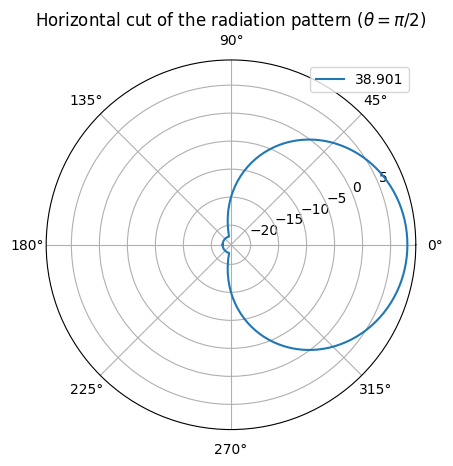

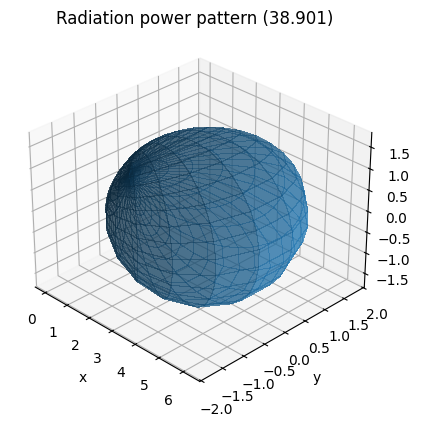

In [19]:
BS_ARRAY.show_element_radiation_pattern();

## Channel Model
The 3GPP 38.901 channel model offers five different delay profiles, called “CDL-A”, “CDL-B”, “CDL-C”, “CDL-D”, and “CDL-E”. The first three model non line-of-sight (NLoS) channels, whereas the last two model line-of-sight (LoS) channels.

In [20]:
DELAY_SPREAD = 100e-9 # Nominal delay spread in [s]. Please see the CDL documentation
                      # about how to choose this value.

DIRECTION = "uplink"  # The `direction` determines if the UT or BS is transmitting.
                      # In the `uplink`, the UT is transmitting.

CDL_MODEL = "C"       # Suitable values are ["A", "B", "C", "D", "E"]

SPEED = 10.0          # UT speed [m/s]. BSs are always assumed to be fixed.
                      # The direction of travel will chosen randomly.

CDL = sn.phy.channel.tr38901.CDL(CDL_MODEL,
                                 DELAY_SPREAD,
                                 CARRIER_FREQUENCY,
                                 UT_ARRAY,
                                 BS_ARRAY,
                                 DIRECTION,
                                 min_speed=SPEED)

In [21]:
BATCH_SIZE = 128 # How many examples are processed by Sionna in parallel

a, tau = CDL(batch_size=BATCH_SIZE,
             num_time_steps=RESOURCE_GRID.num_ofdm_symbols,
             sampling_frequency=1/RESOURCE_GRID.ofdm_symbol_duration)

The path gains a have shape
`[batch size, num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]`

and the delays tau have shape
`[batch_size, num_rx, num_tx, num_paths]`.

In [22]:
print("Shape of the path gains: ", a.shape)
print("Shape of the delays:", tau.shape)

Shape of the path gains:  torch.Size([128, 1, 4, 1, 1, 24, 14])
Shape of the delays: torch.Size([128, 1, 1, 24])


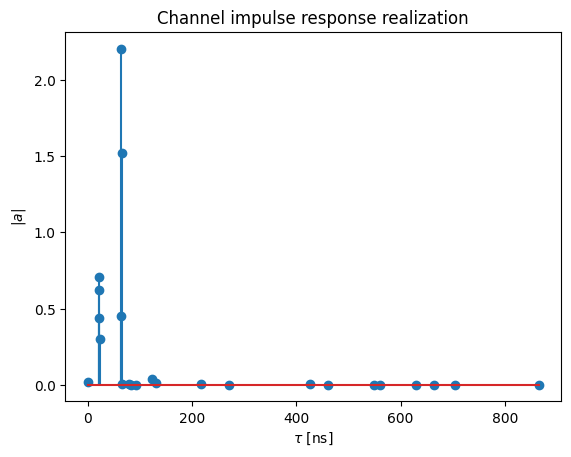

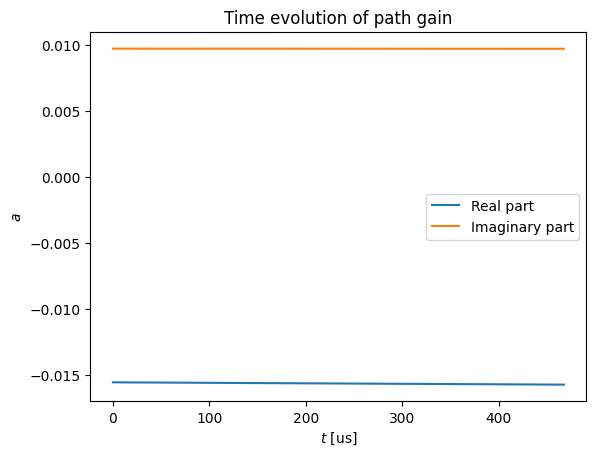

In [23]:
a = a.cpu().numpy()
tau = tau.cpu().numpy()

plt.figure()
plt.title("Channel impulse response realization")
plt.stem(tau[0,0,0,:]/1e-9, np.abs(a)[0,0,0,0,0,:,0])
plt.xlabel(r"$\tau$ [ns]")
plt.ylabel(r"$|a|$")

plt.figure()
plt.title("Time evolution of path gain")
plt.plot(np.arange(RESOURCE_GRID.num_ofdm_symbols)*RESOURCE_GRID.ofdm_symbol_duration/1e-6, np.real(a)[0,0,0,0,0,0,:])
plt.plot(np.arange(RESOURCE_GRID.num_ofdm_symbols)*RESOURCE_GRID.ofdm_symbol_duration/1e-6, np.imag(a)[0,0,0,0,0,0,:])
plt.legend(["Real part", "Imaginary part"])

plt.xlabel(r"$t$ [us]")
plt.ylabel(r"$a$");